# **DATA608 Assignment 2**
## **Prompt**

The Federal Reserve's mandate from Congress is to control inflation and to maintain low unemployment. These seem to be contradictory objectives.

For this story you will need to source the following data for the last 25 years;

The Consumer Price Index (CPI) (Bureau of Labor Statistics)

The FED Funds Rate (FRED) (Federal Reserve Board)

Unemployment Rate  (Bureau of Labor Statistics)

Your Data Visualizations should be designed to answer the question "Has the FED been able to fulfill the mandate given to it by Congress?"

## **Python Packages**

In [251]:
%%capture
!pip install fredapi

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import requests
import json
from datetime import datetime
from fredapi import Fred

## **Data Import**

In [253]:
headers = {'Content-type':'application/json'}
key = 'd585a718221c403e92bca7aaaecff7a7'

cdata = json.dumps({
"seriesid":['CUUR0000SA0'],
"startyear":"2001",
"endyear":"2015",
"registrationkey":key
})
json_cdata = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/',
                           data=cdata,headers=headers).json()
cdata_list = []
for series in json_cdata['Results']['series']:
  seriesID = series['seriesID']
  for item in series['data']:
    cdata_list.append({
      'Series ID':seriesID,
      'Year':int(item['year']),
      'Month':item['period'],
      'value':float(item['value'])
    })

cdata1 = json.dumps({
"seriesid":['CUUR0000SA0'],
"startyear":"2016",
"endyear":"2026",
"registrationkey":key
})
json_cdata1 = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/',
                            data=cdata1,headers=headers).json()
cdata_list1 = []
for series in json_cdata1['Results']['series']:
  seriesID = series['seriesID']
  for item in series['data']:
    cdata_list1.append({
      'Series ID':seriesID,
      'Year':int(item['year']),
      'Month':item['period'],
      'value':item['value']
    })

cpi = pd.concat([pd.DataFrame(cdata_list),
                 pd.DataFrame(cdata_list1)],
                ignore_index=True)

udata = json.dumps({
"seriesid":['LNS14000000'],
"startyear":"2001",
"endyear":"2015",
"registrationkey":key
})
json_udata = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/',
                           data=udata,headers=headers).json()
udata_list = []
for series in json_udata['Results']['series']:
  seriesID = series['seriesID']
  for item in series['data']:
    udata_list.append({
      'Series ID':seriesID,
      'Year':int(item['year']),
      'Month':item['period'],
      'value':float(item['value'])
    })

udata1 = json.dumps({
"seriesid":['LNS14000000'],
"startyear":"2016",
"endyear":"2026",
"registrationkey":key
})
json_udata1 = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/',
                           data=udata1,headers=headers).json()
udata_list1 = []
for series in json_udata1['Results']['series']:
  seriesID = series['seriesID']
  for item in series['data']:
    udata_list1.append({
      'Series ID':seriesID,
      'Year':int(item['year']),
      'Month':item['period'],
      'value':item['value']
    })

ur = pd.concat([pd.DataFrame(udata_list),
                   pd.DataFrame(udata_list1)],
                  ignore_index=True)

fred = Fred(api_key='41ab2ea3b9b12d1ee283df0ddb5528ea')
fed = pd.DataFrame(fred.get_series('FEDFUNDS',observation_start='01/01/2001'))

print("\nCPI Data:\n",cpi.head(),"\n")
print(cpi.tail())
print("\nUnemployment Rate Data:\n",ur.head(),"\n")
print(ur.tail())
print("\nFed Fund Rate Data:\n",fed.head(),"\n")
print(fed.tail())


CPI Data:
      Series ID  Year Month    value
0  CUUR0000SA0  2015   M12  236.525
1  CUUR0000SA0  2015   M11  237.336
2  CUUR0000SA0  2015   M10  237.838
3  CUUR0000SA0  2015   M09  237.945
4  CUUR0000SA0  2015   M08  238.316 

       Series ID  Year Month    value
299  CUUR0000SA0  2016   M05  240.229
300  CUUR0000SA0  2016   M04  239.261
301  CUUR0000SA0  2016   M03  238.132
302  CUUR0000SA0  2016   M02  237.111
303  CUUR0000SA0  2016   M01  236.916

Unemployment Rate Data:
      Series ID  Year Month value
0  LNS14000000  2015   M12   5.0
1  LNS14000000  2015   M11   5.1
2  LNS14000000  2015   M10   5.0
3  LNS14000000  2015   M09   5.0
4  LNS14000000  2015   M08   5.1 

       Series ID  Year Month value
299  LNS14000000  2016   M05   4.8
300  LNS14000000  2016   M04   5.1
301  LNS14000000  2016   M03   5.0
302  LNS14000000  2016   M02   4.9
303  LNS14000000  2016   M01   4.8

Fed Fund Rate Data:
                0
2001-01-01  5.98
2001-02-01  5.49
2001-03-01  5.31
2001-04-01  4.80

## **Data Wrangling**

In [254]:
cpi['Date'] = cpi['Year'].astype(str) + cpi['Month']
cpi.index = cpi['Date'].apply(lambda x: datetime.strptime(x, '%YM%m'))
cpi['Measure'] = 'CPI'
cpi.sort_index(inplace=True)

cpi.at['2025-10-01','value'] = cpi.at['2025-09-01','value']
cpi['YoY'] = cpi['value'].astype(float).pct_change(periods=12)*100
cpi['Relative Value'] = cpi['YoY']/cpi['YoY'].max()

cpi_trim = cpi[['Relative Value','Measure']].dropna()

ur['Date'] = ur['Year'].astype(str) + ur['Month']
ur.index = ur['Date'].apply(lambda x: datetime.strptime(x, '%YM%m'))
ur['Measure'] = 'Unemployment'
ur.sort_index(inplace=True)

ur.at['2025-10-01','value'] = ur.at['2025-09-01','value']
ur['Relative Value'] = ur['value'].astype(float)/ur['value'].astype(float).max()

ur_trim = ur[['Relative Value','Measure']]

print(cpi_trim.head())
print(ur_trim.head())

            Relative Value Measure
Date                              
2002-01-01        0.126074     CPI
2002-02-01        0.125572     CPI
2002-03-01        0.162874     CPI
2002-04-01        0.180948     CPI
2002-05-01        0.130441     CPI
            Relative Value       Measure
Date                                    
2001-01-01        0.283784  Unemployment
2001-02-01        0.283784  Unemployment
2001-03-01        0.290541  Unemployment
2001-04-01        0.297297  Unemployment
2001-05-01        0.290541  Unemployment


In [255]:
fed['Measure'] = 'Fed Rate'
fed['Relative Value'] = fed.iloc[:,0]/fed.iloc[:,0].max()

fed_trim = fed[['Relative Value','Measure']]

print(fed_trim.head())

            Relative Value   Measure
2001-01-01        1.000000  Fed Rate
2001-02-01        0.918060  Fed Rate
2001-03-01        0.887960  Fed Rate
2001-04-01        0.802676  Fed Rate
2001-05-01        0.704013  Fed Rate


In [256]:
all = pd.concat([cpi_trim,ur_trim,fed_trim])

print(all.head())
print(all.tail())

            Relative Value Measure
2002-01-01        0.126074     CPI
2002-02-01        0.125572     CPI
2002-03-01        0.162874     CPI
2002-04-01        0.180948     CPI
2002-05-01        0.130441     CPI
            Relative Value   Measure
2025-12-01        0.622074  Fed Rate
2026-01-01        0.608696  Fed Rate
2026-02-01        0.608696  Fed Rate
2026-03-01        0.608696  Fed Rate
2026-04-01        0.608696  Fed Rate


## **Data Visualizations**

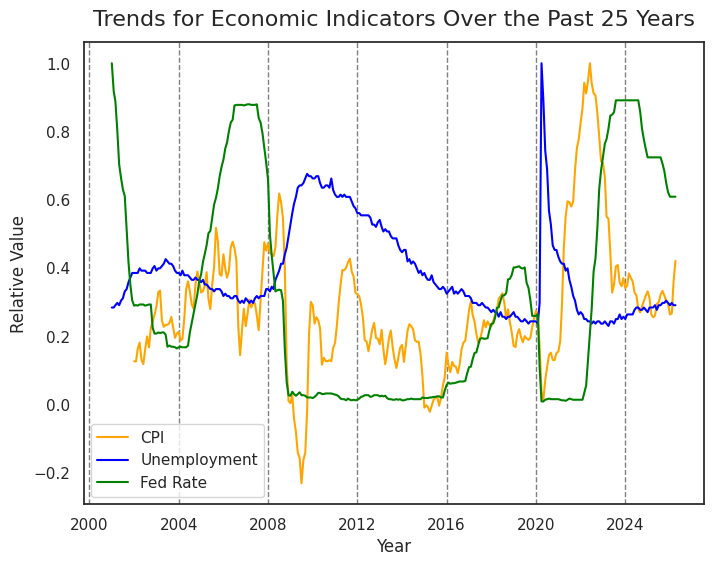

In [262]:
pal = {"CPI":"orange",
       "Unemployment":"blue",
       "Fed Rate":"green"}

fig, ax = plt.subplots()

sns.lineplot(all,x=all.index,y='Relative Value',
                hue='Measure',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8,6)})
sns.set_style('white')
ax.set_title('Trends for Economic Indicators Over the Past 25 Years',
             fontdict={'fontsize':16},pad=12)
ax.set(xlabel='Year')
ax.set(ylabel='Relative Value')
plt.grid(axis='x',color='gray',linestyle='--',linewidth=1)
plt.legend(loc='lower left')

plt.show()

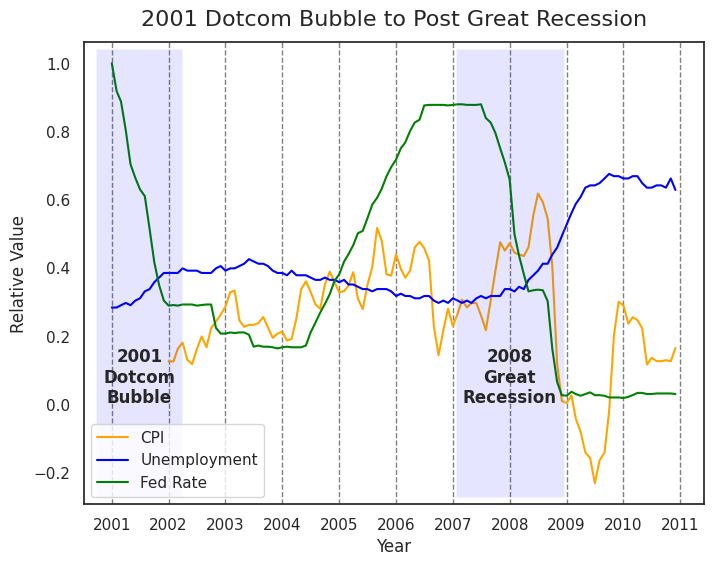

In [258]:
fig, ax = plt.subplots()

sns.lineplot(all[all.index<datetime(2011,1,1)],
             x=all.index[all.index<datetime(2011,1,1)],
             y='Relative Value',
             hue='Measure',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8,6)})
sns.set_style('white')
ax.set_title('2001 Dotcom Bubble to Post Great Recession',
             fontdict={'fontsize':16},pad=12)
ax.set(xlabel='Year')
ax.set(ylabel='Relative Value')
plt.grid(axis='x',color='gray',linestyle='--',linewidth=1)
plt.legend(loc='lower left')
plt.text(11500,-0.24,"\n\n\n\n\n\n\n\n\n\n\n\n\n\n2001\nDotcom\nBubble"
                     "\n\n\n\n",
         fontweight='bold',
         horizontalalignment='center',
         bbox=dict(facecolor="blue",alpha=0.1,pad=5))
plt.text(13880,-0.24,"\n\n\n\n\n\n\n\n\n\n\n\n\n\n2008\nGreat\nRecession"
                     "\n\n\n\n",
         fontweight='bold',
         horizontalalignment='center',
         bbox=dict(facecolor="blue",alpha=0.1,pad=5))

plt.show()

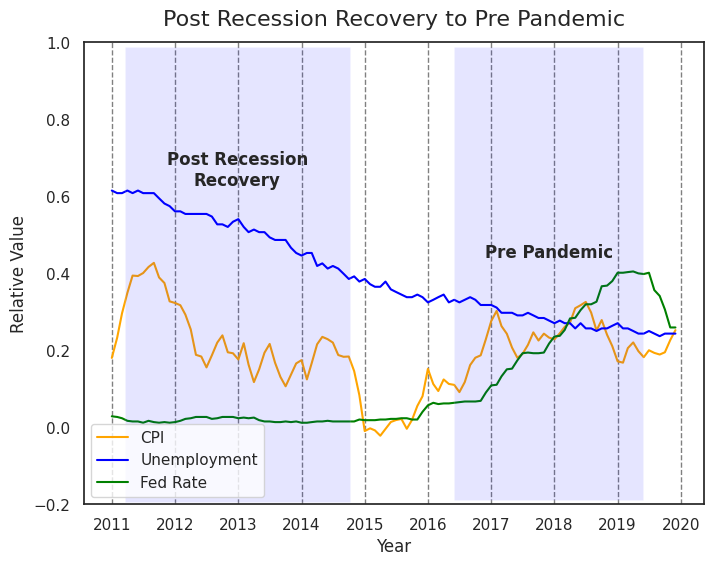

In [259]:
fig, ax = plt.subplots()

sns.lineplot(all[(all.index>=datetime(2011,1,1))&(all.index<datetime(2020,1,1))],
             x=all.index[(all.index>=datetime(2011,1,1))&(all.index<datetime(2020,1,1))],
             y='Relative Value',
             hue='Measure',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8,6)})
sns.set_style('white')
ax.set_title('Post Recession Recovery to Pre Pandemic',
             fontdict={'fontsize':16},pad=12)
ax.set(xlabel='Year')
ax.set(ylabel='Relative Value')
ax.set_ylim(bottom=-0.2,top=1.0)
plt.grid(axis='x',color='gray',linestyle='--',linewidth=1)
plt.legend(loc='lower left')
plt.text(15700,-0.075,"\n\n\nPost Recession\nRecovery"
                     "\n\n\n\n\n\n\n\n\n\n\n\n\n",
         fontweight='bold',
         horizontalalignment='center',
         bbox=dict(facecolor="blue",alpha=0.1,pad=30))
plt.text(17500,-0.1,"\n\n\n\n\n\n\n\nPre Pandemic"
                     "\n\n\n\n\n\n\n\n\n\n",
         fontweight='bold',
         horizontalalignment='center',
         bbox=dict(facecolor="blue",alpha=0.1,pad=22))

plt.show()

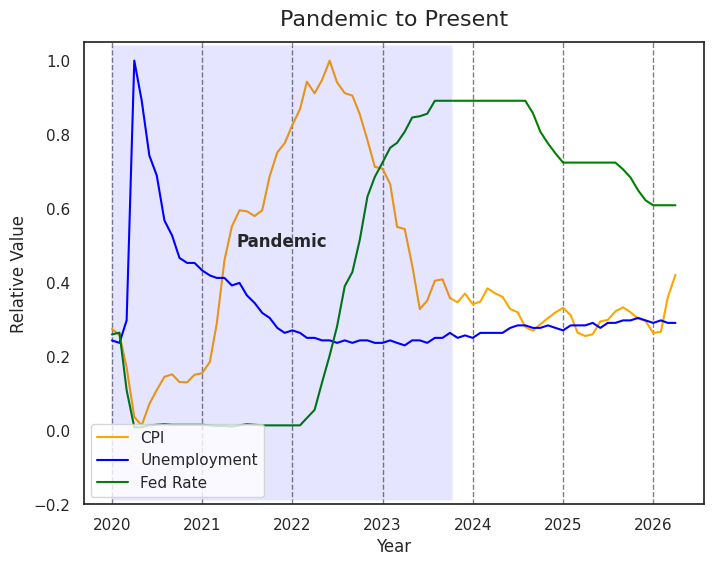

In [260]:
fig, ax = plt.subplots()

sns.lineplot(all[all.index>=datetime(2020,1,1)],
             x=all.index[all.index>=datetime(2020,1,1)],
             y='Relative Value',
             hue='Measure',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8,6)})
sns.set_style('white')
ax.set_title('Pandemic to Present',
             fontdict={'fontsize':16},pad=12)
ax.set(xlabel='Year')
ax.set(ylabel='Relative Value')
ax.set_ylim(bottom=-0.2)
plt.grid(axis='x',color='gray',linestyle='--',linewidth=1)
plt.legend(loc='lower left')
plt.text(18950,0.16,"\n\n\nPandemic\n\n\n\n\n\n",
         fontweight='bold',
         horizontalalignment='center',
         bbox=dict(facecolor="blue",alpha=0.1,pad=90))

plt.show()

## **Sources**

CPI and Unemployment Data:

https://data.bls.gov/pdq/SurveyOutputServlet

Fed Fund Rate Data:

https://fred.stlouisfed.org/series/fedfunds